🔵 BAYESIAN LINEAR REGRESSION - DATASET 1 (HOUSE PRICE)

📁 Please upload your House Price Prediction CSV file:


Saving houses.csv to houses (1).csv

✅ Dataset Loaded: houses (1).csv
📊 Shape: (1000, 18)

📋 Columns in dataset:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'price']


👉 Enter the target column name (e.g., price, SalePrice, medv): price

🔄 Preprocessing Dataset 1...
✅ Features: 17
✅ Target samples: 1000

📊 Train size: 800
📊 Test size: 200

🚀 Training Bayesian Linear Regression on Dataset 1...
Convergence after  3  iterations
✅ Training Complete!

📊 EVALUATION RESULTS - DATASET 1

📈 Training Results:
   R² Score  : 0.7265
   RMSE      : 17.7855
   MAE       : 11.6545
   MAPE      : 23.99%

📈 Testing Results:
   R² Score  : 0.7219
   RMSE      : 17.7194
   MAE       : 10.7305
   MAPE      : 22.78%

📋 HYPERPARAMETERS USED
    Parameter     Value
      alpha_1  0.000001
      alpha_2  0.000001
     lambda_1  0.000001
     lambd

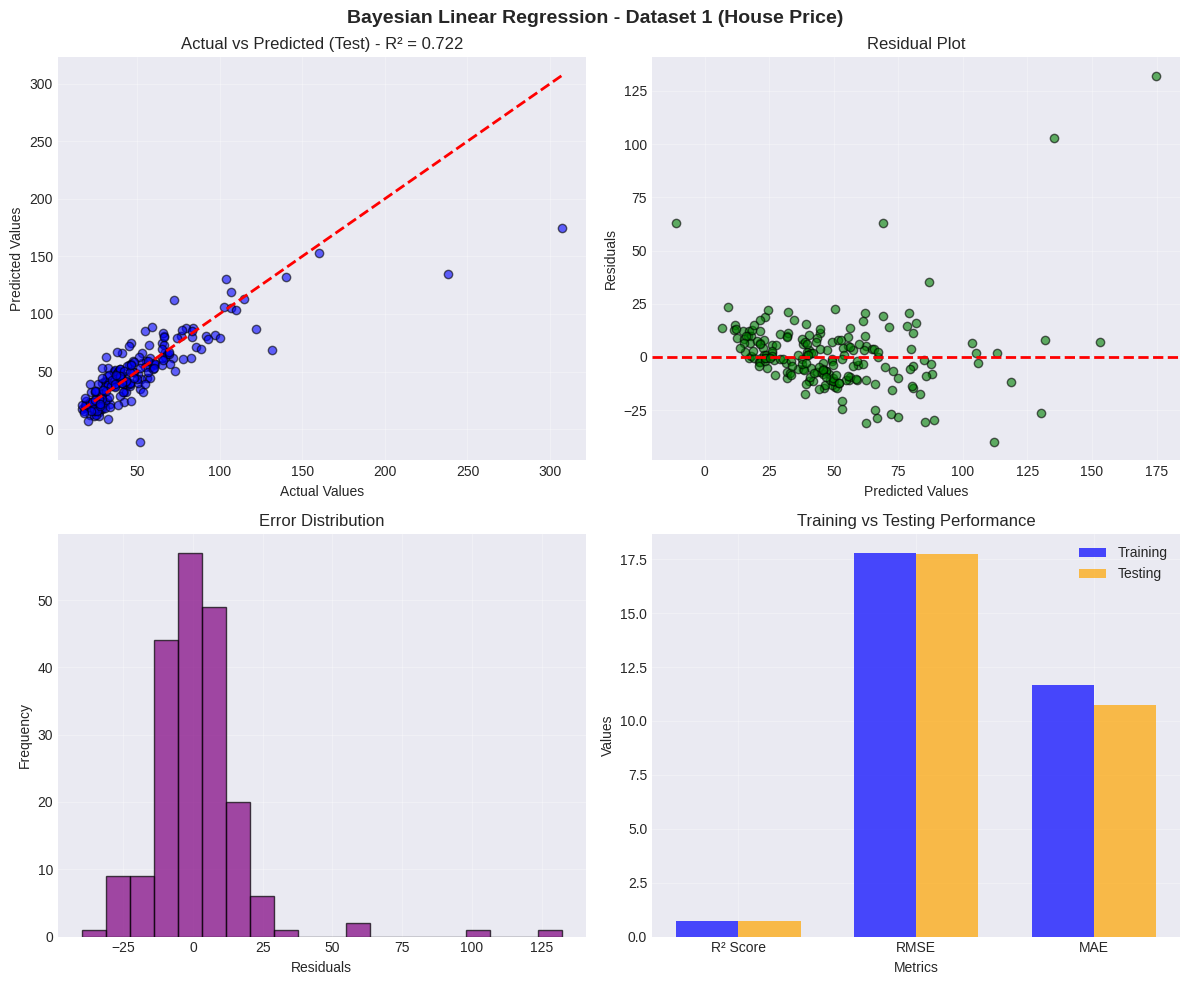


📊 FINAL RESULTS TABLE - DATASET 1
  Metric  Training   Testing
R² Score  0.726458  0.721871
    RMSE 17.785549 17.719409
     MAE 11.654468 10.730498
MAPE (%) 23.991055 22.777130

✅ Results saved to 'dataset1_house_price_results.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DATASET 1 EXPERIMENTATION COMPLETED!


In [5]:
# ============================================
# CODE 1: BAYESIAN LINEAR REGRESSION
# DATASET 1: HOUSE PRICE PREDICTION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from google.colab import files

print("="*60)
print("🔵 BAYESIAN LINEAR REGRESSION - DATASET 1 (HOUSE PRICE)")
print("="*60)

# ============================================
# 1. UPLOAD DATASET
# ============================================
print("\n📁 Please upload your House Price Prediction CSV file:")
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"\n✅ Dataset Loaded: {file_name}")
print(f"📊 Shape: {df.shape}")
print(f"\n📋 Columns in dataset:")
print(df.columns.tolist())

# ============================================
# 2. SPECIFY TARGET COLUMN
# ============================================
print("\n" + "="*60)
target_col = input("\n👉 Enter the target column name (e.g., price, SalePrice, medv): ")

# Check if target column exists
if target_col not in df.columns:
    print(f"\n❌ '{target_col}' not found! Available columns: {df.columns.tolist()}")
    target_col = input("Re-enter correct target column name: ")

# ============================================
# 3. DATA PREPROCESSING
# ============================================
print("\n🔄 Preprocessing Dataset 1...")

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Remove infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print(f"✅ Features: {X.shape[1]}")
print(f"✅ Target samples: {y.shape[0]}")

# ============================================
# 4. TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n📊 Train size: {X_train.shape[0]}")
print(f"📊 Test size: {X_test.shape[0]}")

# ============================================
# 5. FEATURE SCALING
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 6. TRAIN BAYESIAN LINEAR REGRESSION
# ============================================
print("\n🚀 Training Bayesian Linear Regression on Dataset 1...")

model = BayesianRidge(
    alpha_1=1e-6,      # Prior precision
    alpha_2=1e-6,
    lambda_1=1e-6,     # Likelihood precision
    lambda_2=1e-6,
    fit_intercept=True,
    max_iter=300,
    tol=1e-3,
    verbose=True
)

model.fit(X_train_scaled, y_train)
print("✅ Training Complete!")

# ============================================
# 7. PREDICTIONS
# ============================================
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================
# 8. EVALUATION METRICS
# ============================================
def calculate_metrics(y_true, y_pred, dataset_type):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📈 {dataset_type} Results:")
    print(f"   R² Score  : {r2:.4f}")
    print(f"   RMSE      : {rmse:.4f}")
    print(f"   MAE       : {mae:.4f}")
    print(f"   MAPE      : {mape:.2f}%")

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

print("\n" + "="*60)
print("📊 EVALUATION RESULTS - DATASET 1")
print("="*60)

train_metrics = calculate_metrics(y_train, y_train_pred, "Training")
test_metrics = calculate_metrics(y_test, y_test_pred, "Testing")

# ============================================
# 9. HYPERPARAMETERS TABLE
# ============================================
print("\n" + "="*60)
print("📋 HYPERPARAMETERS USED")
print("="*60)

hyperparams = {
    'Parameter': ['alpha_1', 'alpha_2', 'lambda_1', 'lambda_2', 'fit_intercept', 'max_iter', 'tol', 'random_state'],
    'Value': [1e-6, 1e-6, 1e-6, 1e-6, True, 300, 1e-3, 42]
}
hyper_df = pd.DataFrame(hyperparams)
print(hyper_df.to_string(index=False))

# ============================================
# 10. GRAPHS FOR DATASET 1
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Bayesian Linear Regression - Dataset 1 (House Price)', fontsize=14, fontweight='bold')

# Graph 1: Actual vs Predicted (Test)
axes[0,0].scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Values')
axes[0,0].set_ylabel('Predicted Values')
axes[0,0].set_title(f'Actual vs Predicted (Test) - R² = {test_metrics["R2"]:.3f}')
axes[0,0].grid(True, alpha=0.3)

# Graph 2: Residual Plot
residuals = y_test - y_test_pred
axes[0,1].scatter(y_test_pred, residuals, alpha=0.6, color='green', edgecolors='black')
axes[0,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True, alpha=0.3)

# Graph 3: Error Distribution
axes[1,0].hist(residuals, bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Error Distribution')
axes[1,0].grid(True, alpha=0.3)

# Graph 4: Training vs Testing R² Comparison
metrics_plot = ['R² Score', 'RMSE', 'MAE']
train_values = [train_metrics['R2'], train_metrics['RMSE'], train_metrics['MAE']]
test_values = [test_metrics['R2'], test_metrics['RMSE'], test_metrics['MAE']]

x = np.arange(len(metrics_plot))
width = 0.35
axes[1,1].bar(x - width/2, train_values, width, label='Training', color='blue', alpha=0.7)
axes[1,1].bar(x + width/2, test_values, width, label='Testing', color='orange', alpha=0.7)
axes[1,1].set_xlabel('Metrics')
axes[1,1].set_ylabel('Values')
axes[1,1].set_title('Training vs Testing Performance')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metrics_plot)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 11. SAVE RESULTS FOR DATASET 1
# ============================================
results_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE', 'MAPE (%)'],
    'Training': [train_metrics['R2'], train_metrics['RMSE'], train_metrics['MAE'], train_metrics['MAPE']],
    'Testing': [test_metrics['R2'], test_metrics['RMSE'], test_metrics['MAE'], test_metrics['MAPE']]
})

print("\n" + "="*60)
print("📊 FINAL RESULTS TABLE - DATASET 1")
print("="*60)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('dataset1_house_price_results.csv', index=False)
print("\n✅ Results saved to 'dataset1_house_price_results.csv'")
files.download('dataset1_house_price_results.csv')

print("\n" + "="*60)
print("✅ DATASET 1 EXPERIMENTATION COMPLETED!")
print("="*60)